# Assignment 8

## Q1: IPASS Trial – Progression-Free Survival

### a) KM plot of PFS by arm with risk table

Loading required package: ggplot2

Loading required package: ggpubr


Attaching package: ‘survminer’


The following object is masked from ‘package:survival’:

    myeloma


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggpubr package.
  Please report the issue at <https://github.com/kassambara/ggpubr/issues>.”
Ignoring unknown labels:
• linetype : "1"
Ignoring unknown labels:
• linetype : "1"
Ignoring unknown labels:
• linetype : "1"
Ignoring unknown labels:
• linetype : "1"
Ignoring unknown labels:
• colour : "Arm"


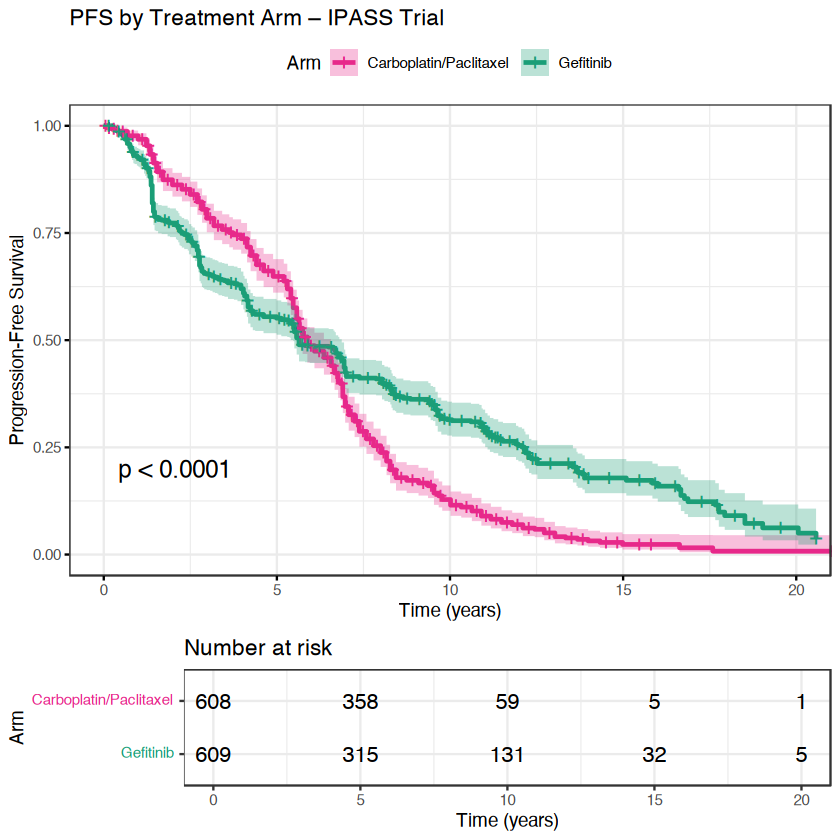

In [ ]:
library(AHSurv)
library(survival)
library(survminer)

data(ipass)

# arm: 0 = chemotherapy, 1 = gefitinib (from IPASS trial)
ipass$arm_label <- factor(ipass$arm, levels = c(0, 1),
                          labels = c("Carboplatin/Paclitaxel-0", "Gefitinib-1"))

fit <- survfit(Surv(time, status) ~ arm_label, data = ipass)

ggsurvplot(
  fit,
  data          = ipass,
  risk.table    = TRUE,
  pval          = TRUE,
  conf.int      = TRUE,
  censor = TRUE,
  xlab          = "Time (years)",
  ylab          = "Progression-Free Survival",
  title         = "PFS by Treatment Arm – IPASS Trial",
  legend.title  = "Arm",
  legend.labs   = c("Carboplatin/Paclitaxel", "Gefitinib"),
  palette       = c("#E7298A", "#1B9E77"),
  risk.table.height = 0.25,
  ggtheme       = theme_bw()
)

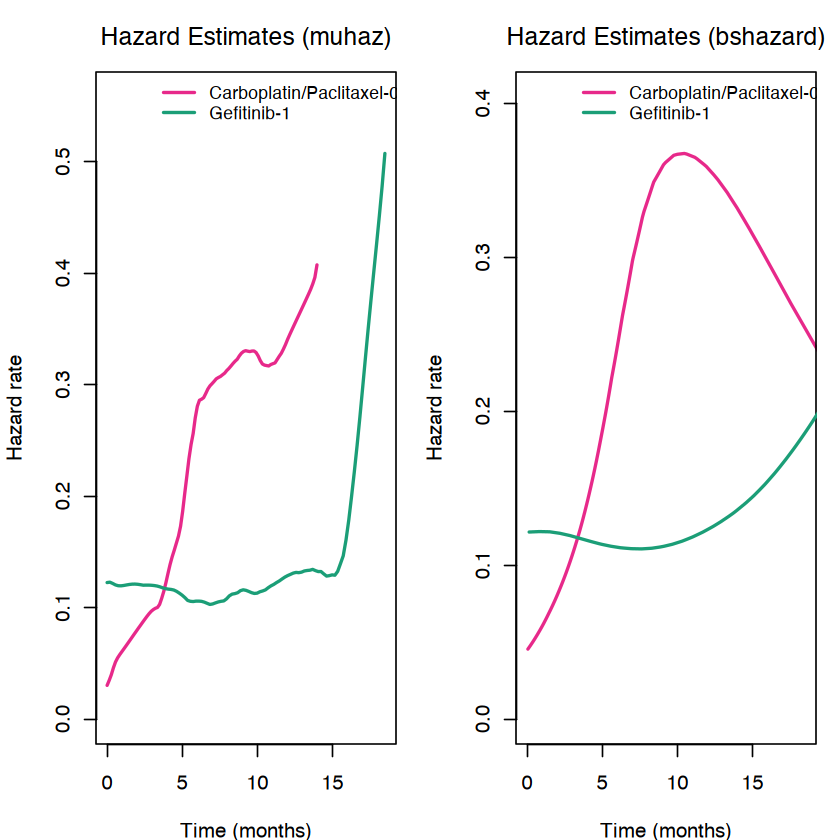

In [4]:
# ── Q1b: Hazard rate estimates ─────────────────────────────────────────────
library(muhaz)
library(bshazard)

ipass0 <- subset(ipass, arm == 0)
ipass1 <- subset(ipass, arm == 1)

mh0 <- muhaz(ipass0$time, ipass0$status)
mh1 <- muhaz(ipass1$time, ipass1$status)

suppressWarnings({
  bs0 <- bshazard(Surv(time, status) ~ 1, data = ipass0, verbose = FALSE)
  bs1 <- bshazard(Surv(time, status) ~ 1, data = ipass1, verbose = FALSE)
})

par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))

xlim <- range(mh0$est.grid, mh1$est.grid)
ylim <- c(0, max(mh0$haz.est, mh1$haz.est) * 1.1)
plot(mh0, col = "#E7298A", lwd = 2,
     xlim = xlim, ylim = ylim,
     xlab = "Time (months)", ylab = "Hazard rate",
     main = "Hazard Estimates (muhaz)")
lines(mh1$est.grid, mh1$haz.est, col = "#1B9E77", lwd = 2)
legend("topright", legend = c("Carboplatin/Paclitaxel-0", "Gefitinib-1"),
       col = c("#E7298A", "#1B9E77"), lwd = 2, bty = "n", cex = 0.85)

ylim2 <- c(0, max(bs0$hazard, bs1$hazard) * 1.1)
plot(bs0$time, bs0$hazard, type = "l", col = "#E7298A", lwd = 2,
     xlim = xlim, ylim = ylim2,
     xlab = "Time (months)", ylab = "Hazard rate",
     main = "Hazard Estimates (bshazard)")
lines(bs1$time, bs1$hazard, col = "#1B9E77", lwd = 2)
legend("topright", legend = c("Carboplatin/Paclitaxel-0", "Gefitinib-1"),
       col = c("#E7298A", "#1B9E77"), lwd = 2, bty = "n", cex = 0.85)

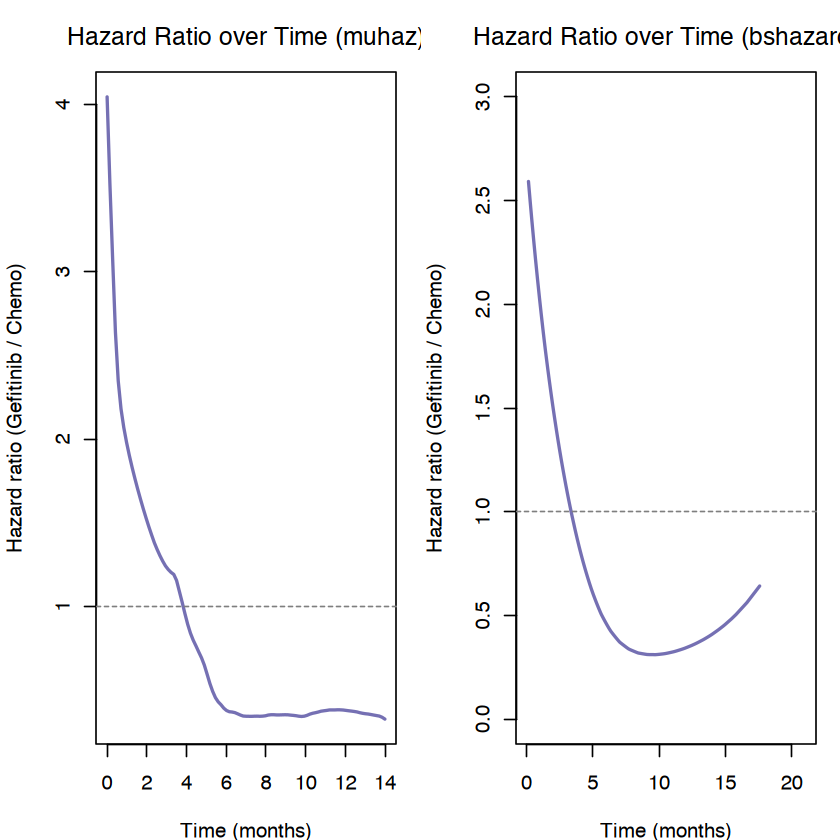

In [8]:
# ── Q1c: Hazard ratio over time ────────────────────────────────────────────
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))

# muhaz-based HR: gefitinib / chemotherapy on shared grid
t_grid <- mh0$est.grid
h0_interp <- approx(mh0$est.grid, mh0$haz.est, xout = t_grid)$y
h1_interp <- approx(mh1$est.grid, mh1$haz.est, xout = t_grid)$y
hr_muhaz  <- h1_interp / h0_interp

plot(t_grid, hr_muhaz, type = "l", lwd = 2, col = "#7570B3",
     xlab = "Time (months)", ylab = "Hazard ratio (Gefitinib / Chemo)",
     main = "Hazard Ratio over Time (muhaz)")
abline(h = 1, lty = 2, col = "gray50")

# bshazard-based HR: interpolate bs1 onto bs0 time grid
t_bs   <- bs0$time
h0_bs  <- bs0$hazard
h1_bs  <- approx(bs1$time, bs1$hazard, xout = t_bs)$y
hr_bs  <- h1_bs / h0_bs

# Remove CI calculation and filtering
plot(t_bs, hr_bs, type = "l", lwd = 2, col = "#7570B3",
     ylim = c(0, max(hr_bs, 3, na.rm = TRUE)),
     xlab = "Time (months)", ylab = "Hazard ratio (Gefitinib / Chemo)",
     main = "Hazard Ratio over Time (bshazard)")
abline(h = 1, lty = 2, col = "gray50")

           Arm         Dist      AIC
2  Carbo/Pacli      Weibull 2782.533
5  Carbo/Pacli        Gamma 2805.047
6  Carbo/Pacli     Gompertz 2822.814
4  Carbo/Pacli Log-logistic 2852.085
3  Carbo/Pacli   Log-normal 2912.784
1  Carbo/Pacli  Exponential 2990.768
9    Gefitinib   Log-normal 2789.368
10   Gefitinib Log-logistic 2808.501
11   Gefitinib        Gamma 2809.087
8    Gefitinib      Weibull 2811.681
7    Gefitinib  Exponential 2813.386
12   Gefitinib     Gompertz 2814.843


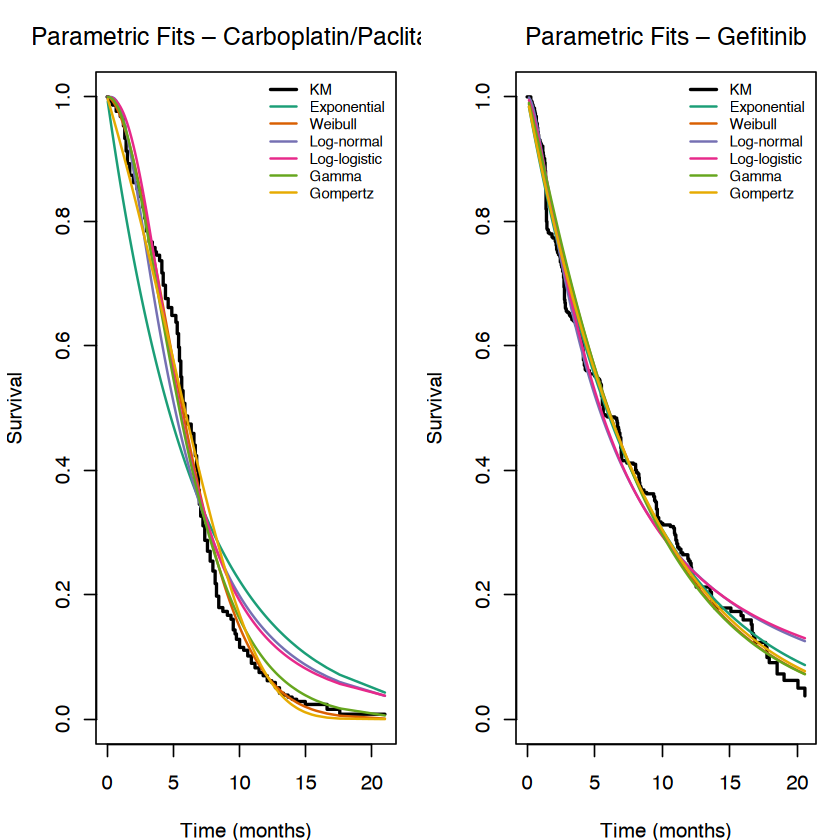

In [10]:
# ── Q1d: Parametric distribution fits ─────────────────────────────────────
library(flexsurv)
library(RColorBrewer)

dists <- c("exp", "weibull", "lnorm", "llogis", "gamma", "gompertz")
dist_labels <- c("Exponential", "Weibull", "Log-normal",
                 "Log-logistic", "Gamma", "Gompertz")

fit_arm <- function(data) {
  lapply(dists, function(d) flexsurvreg(Surv(time, status) ~ 1, data = data, dist = d))
}

fits0 <- fit_arm(ipass0)
fits1 <- fit_arm(ipass1)

# AIC comparison table
aic_table <- function(fits, arm_name) {
  data.frame(Arm = arm_name, Dist = dist_labels, AIC = sapply(fits, AIC),
             row.names = NULL)
}
aic_df <- rbind(aic_table(fits0, "Carbo/Pacli"), aic_table(fits1, "Gefitinib"))
print(aic_df[order(aic_df$Arm, aic_df$AIC), ])

# KM + parametric survival curves
km0  <- survfit(Surv(time, status) ~ 1, data = ipass0)
km1  <- survfit(Surv(time, status) ~ 1, data = ipass1)
cols <- brewer.pal(length(dists), "Dark2")

par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))

plot(km0, conf.int = FALSE, col = "black", lwd = 2,
     xlab = "Time (months)", ylab = "Survival",
     main = "Parametric Fits – Carboplatin/Paclitaxel")
for (i in seq_along(fits0)) lines(fits0[[i]], col = cols[i], lwd = 1.5, ci = FALSE)
legend("topright", legend = c("KM", dist_labels),
       col = c("black", cols), lwd = c(2, rep(1.5, length(dists))),
       bty = "n", cex = 0.72)

plot(km1, conf.int = FALSE, col = "black", lwd = 2,
     xlab = "Time (months)", ylab = "Survival",
     main = "Parametric Fits – Gefitinib")
for (i in seq_along(fits1)) lines(fits1[[i]], col = cols[i], lwd = 1.5, ci = FALSE)
legend("topright", legend = c("KM", dist_labels),
       col = c("black", cols), lwd = c(2, rep(1.5, length(dists))),
       bty = "n", cex = 0.72)

Because the objective is to compare parametric distributions for goodness-of-fit rather than identify a true finite-dimensional model, AIC is appropriate as the primary criterion. BIC may also be reported as a sensitivity analysis favoring more parsimonious models.

### exponential

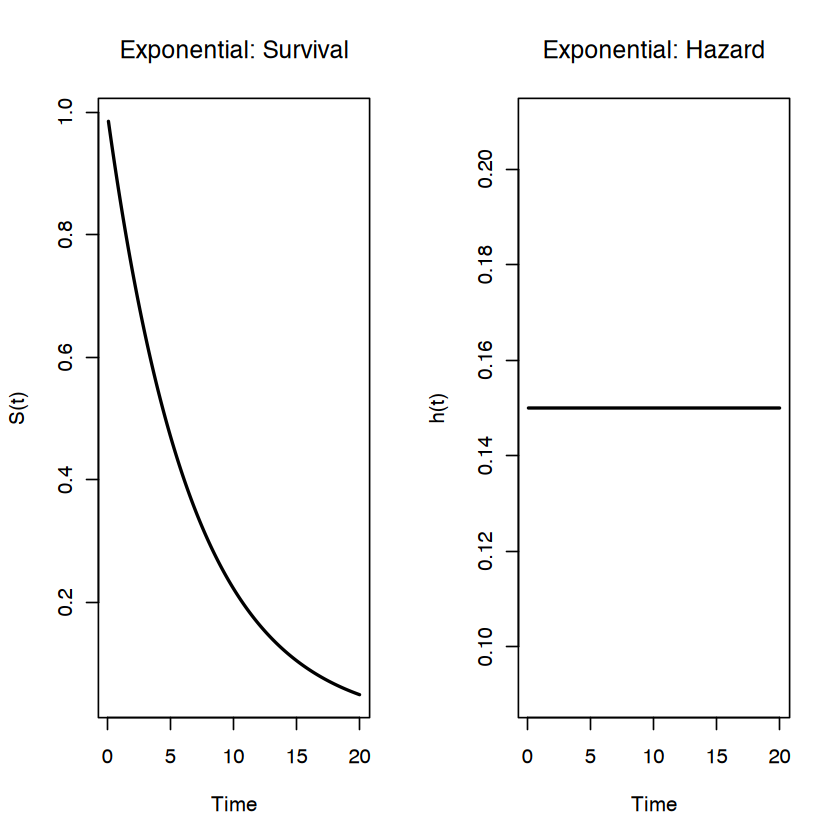

In [12]:
t <- seq(0.1, 20, by = 0.1)

lambda <- 0.15
S_exp <- exp(-lambda * t)
h_exp <- rep(lambda, length(t))

par(mfrow = c(1,2))
plot(t, S_exp, type = "l", lwd = 2,
     main = "Exponential: Survival", xlab = "Time", ylab = "S(t)")
plot(t, h_exp, type = "l", lwd = 2,
     main = "Exponential: Hazard", xlab = "Time", ylab = "h(t)")

### Weibull

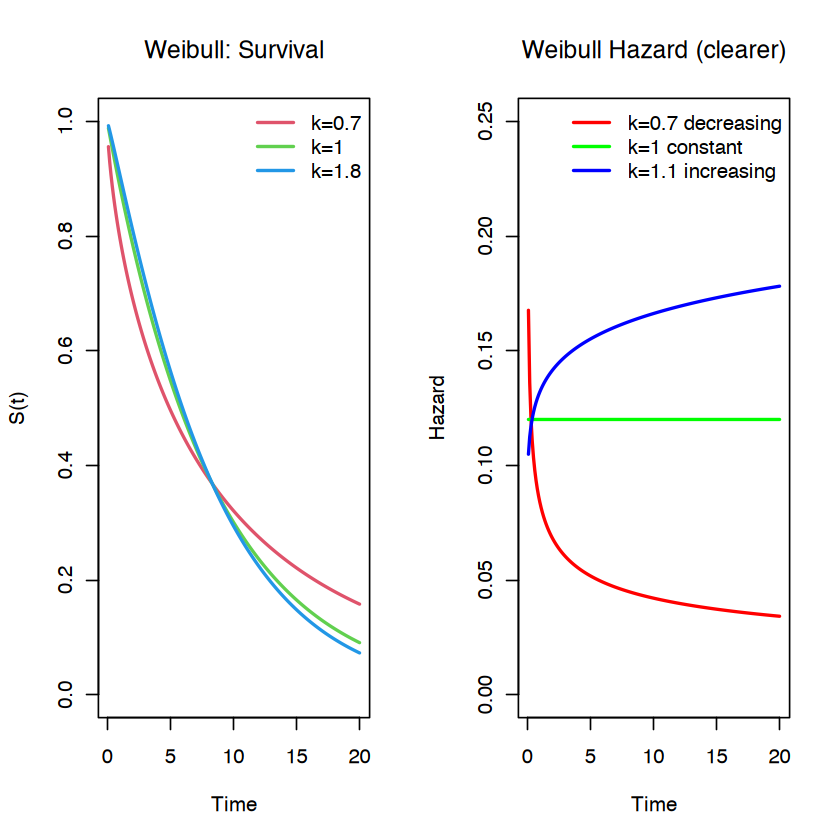

In [19]:
t <- seq(0.1, 20, by = 0.1)

lambda <- 0.12
k1 <- 0.7
k2 <- 1
k3 <- 1.1

S_w1 <- exp(-(lambda * t)^k1)
S_w2 <- exp(-(lambda * t)^k2)
S_w3 <- exp(-(lambda * t)^k3)

h_w1 <- lambda * k1 * t^(k1 - 1)
h_w2 <- lambda * k2 * t^(k2 - 1)
h_w3 <- lambda * k3 * t^(k3 - 1)

par(mfrow = c(1,2))
plot(t, S_w1, type = "l", lwd = 2, col = 2,
     ylim = c(0,1), main = "Weibull: Survival",
     xlab = "Time", ylab = "S(t)")
lines(t, S_w2, lwd = 2, col = 3)
lines(t, S_w3, lwd = 2, col = 4)
legend("topright", legend = c("k=0.7", "k=1", "k=1.8"),
       col = 2:4, lwd = 2, bty = "n")

plot(t,h_w1,type="l",lwd=2,col="red",
     ylim=c(0,0.25),
     xlab="Time",ylab="Hazard",
     main="Weibull Hazard (clearer)")
lines(t,h_w2,lwd=2,col="green")
lines(t,h_w3,lwd=2,col="blue")

legend("topright",
legend=c("k=0.7 decreasing",
         "k=1 constant",
         "k=1.1 increasing"),
col=c("red","green","blue"),
lwd=2,bty="n")

### Log normal

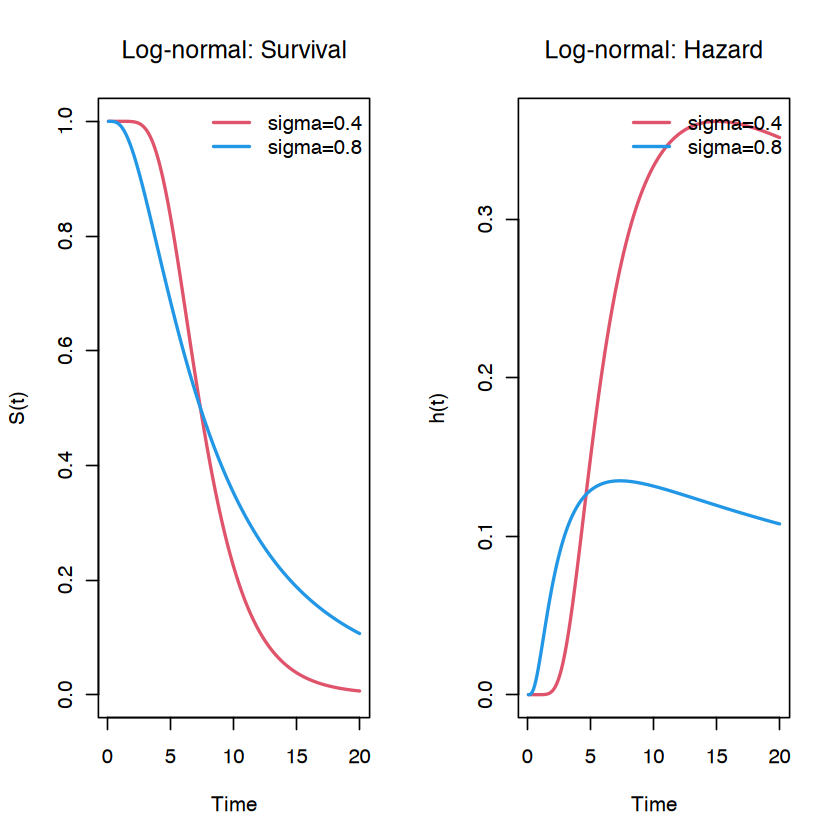

In [20]:
t <- seq(0.1, 20, by = 0.1)

mu <- 2
sigma1 <- 0.4
sigma2 <- 0.8

S_ln1 <- 1 - plnorm(t, meanlog = mu, sdlog = sigma1)
S_ln2 <- 1 - plnorm(t, meanlog = mu, sdlog = sigma2)

f_ln1 <- dlnorm(t, meanlog = mu, sdlog = sigma1)
f_ln2 <- dlnorm(t, meanlog = mu, sdlog = sigma2)

h_ln1 <- f_ln1 / S_ln1
h_ln2 <- f_ln2 / S_ln2

par(mfrow = c(1,2))
plot(t, S_ln1, type = "l", lwd = 2, col = 2,
     ylim = c(0,1), main = "Log-normal: Survival",
     xlab = "Time", ylab = "S(t)")
lines(t, S_ln2, lwd = 2, col = 4)
legend("topright", legend = c("sigma=0.4", "sigma=0.8"),
       col = c(2,4), lwd = 2, bty = "n")

plot(t, h_ln1, type = "l", lwd = 2, col = 2,
     main = "Log-normal: Hazard", xlab = "Time", ylab = "h(t)")
lines(t, h_ln2, lwd = 2, col = 4)
legend("topright", legend = c("sigma=0.4", "sigma=0.8"),
       col = c(2,4), lwd = 2, bty = "n")

### Log-logistic

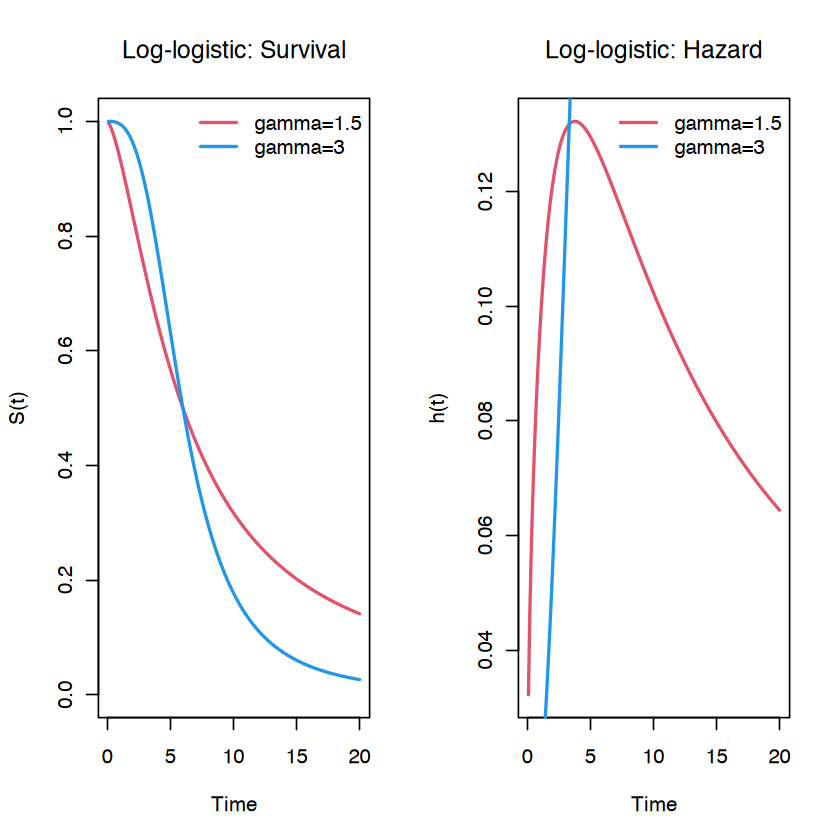

In [21]:
t <- seq(0.1, 20, by = 0.1)

alpha <- 6
gamma1 <- 1.5
gamma2 <- 3

S_ll1 <- 1 / (1 + (t / alpha)^gamma1)
S_ll2 <- 1 / (1 + (t / alpha)^gamma2)

h_ll1 <- ((gamma1 / alpha) * (t / alpha)^(gamma1 - 1)) / (1 + (t / alpha)^gamma1)
h_ll2 <- ((gamma2 / alpha) * (t / alpha)^(gamma2 - 1)) / (1 + (t / alpha)^gamma2)

par(mfrow = c(1,2))
plot(t, S_ll1, type = "l", lwd = 2, col = 2,
     ylim = c(0,1), main = "Log-logistic: Survival",
     xlab = "Time", ylab = "S(t)")
lines(t, S_ll2, lwd = 2, col = 4)
legend("topright", legend = c("gamma=1.5", "gamma=3"),
       col = c(2,4), lwd = 2, bty = "n")

plot(t, h_ll1, type = "l", lwd = 2, col = 2,
     main = "Log-logistic: Hazard", xlab = "Time", ylab = "h(t)")
lines(t, h_ll2, lwd = 2, col = 4)
legend("topright", legend = c("gamma=1.5", "gamma=3"),
       col = c(2,4), lwd = 2, bty = "n")

### Gamma

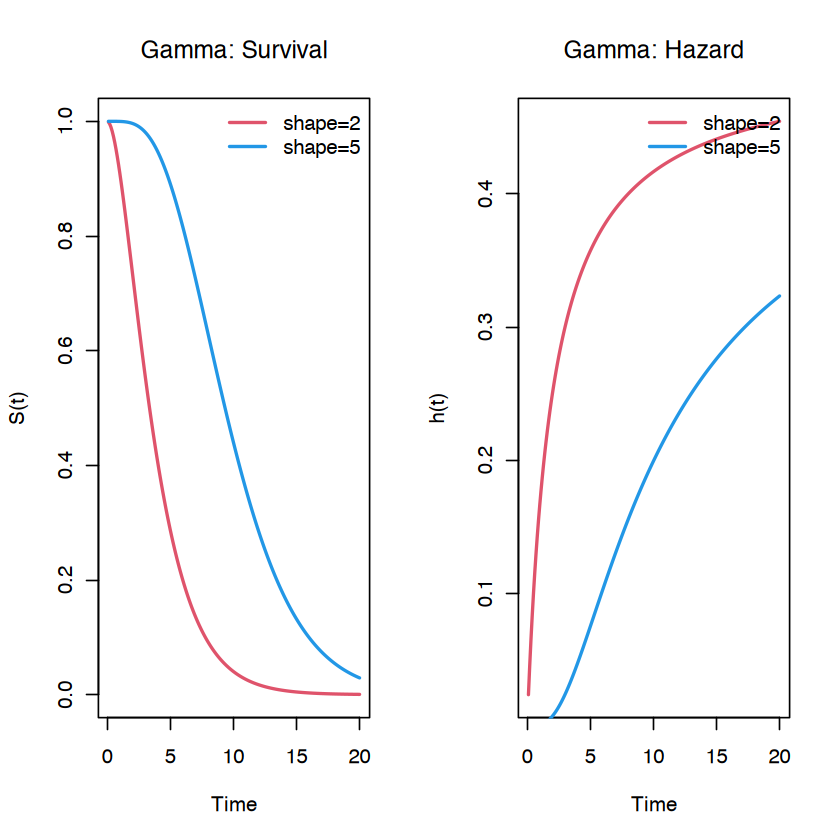

In [22]:
t <- seq(0.1, 20, by = 0.1)

shape1 <- 2
shape2 <- 5
rate <- 0.5

S_g1 <- 1 - pgamma(t, shape = shape1, rate = rate)
S_g2 <- 1 - pgamma(t, shape = shape2, rate = rate)

f_g1 <- dgamma(t, shape = shape1, rate = rate)
f_g2 <- dgamma(t, shape = shape2, rate = rate)

h_g1 <- f_g1 / S_g1
h_g2 <- f_g2 / S_g2

par(mfrow = c(1,2))
plot(t, S_g1, type = "l", lwd = 2, col = 2,
     ylim = c(0,1), main = "Gamma: Survival",
     xlab = "Time", ylab = "S(t)")
lines(t, S_g2, lwd = 2, col = 4)
legend("topright", legend = c("shape=2", "shape=5"),
       col = c(2,4), lwd = 2, bty = "n")

plot(t, h_g1, type = "l", lwd = 2, col = 2,
     main = "Gamma: Hazard", xlab = "Time", ylab = "h(t)")
lines(t, h_g2, lwd = 2, col = 4)
legend("topright", legend = c("shape=2", "shape=5"),
       col = c(2,4), lwd = 2, bty = "n")

### Gompertz

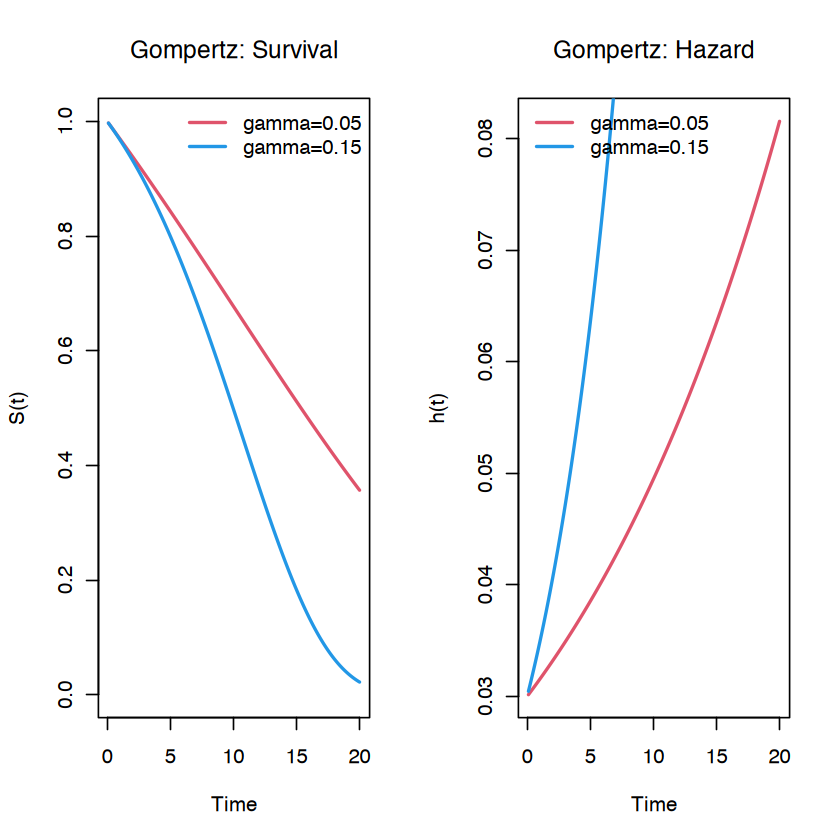

In [23]:
t <- seq(0.1, 20, by = 0.1)

lambda <- 0.03
g1 <- 0.05
g2 <- 0.15

h_go1 <- lambda * exp(g1 * t)
h_go2 <- lambda * exp(g2 * t)

S_go1 <- exp(-(lambda / g1) * (exp(g1 * t) - 1))
S_go2 <- exp(-(lambda / g2) * (exp(g2 * t) - 1))

par(mfrow = c(1,2))
plot(t, S_go1, type = "l", lwd = 2, col = 2,
     ylim = c(0,1), main = "Gompertz: Survival",
     xlab = "Time", ylab = "S(t)")
lines(t, S_go2, lwd = 2, col = 4)
legend("topright", legend = c("gamma=0.05", "gamma=0.15"),
       col = c(2,4), lwd = 2, bty = "n")

plot(t, h_go1, type = "l", lwd = 2, col = 2,
     main = "Gompertz: Hazard", xlab = "Time", ylab = "h(t)")
lines(t, h_go2, lwd = 2, col = 4)
legend("topleft", legend = c("gamma=0.05", "gamma=0.15"),
       col = c(2,4), lwd = 2, bty = "n")

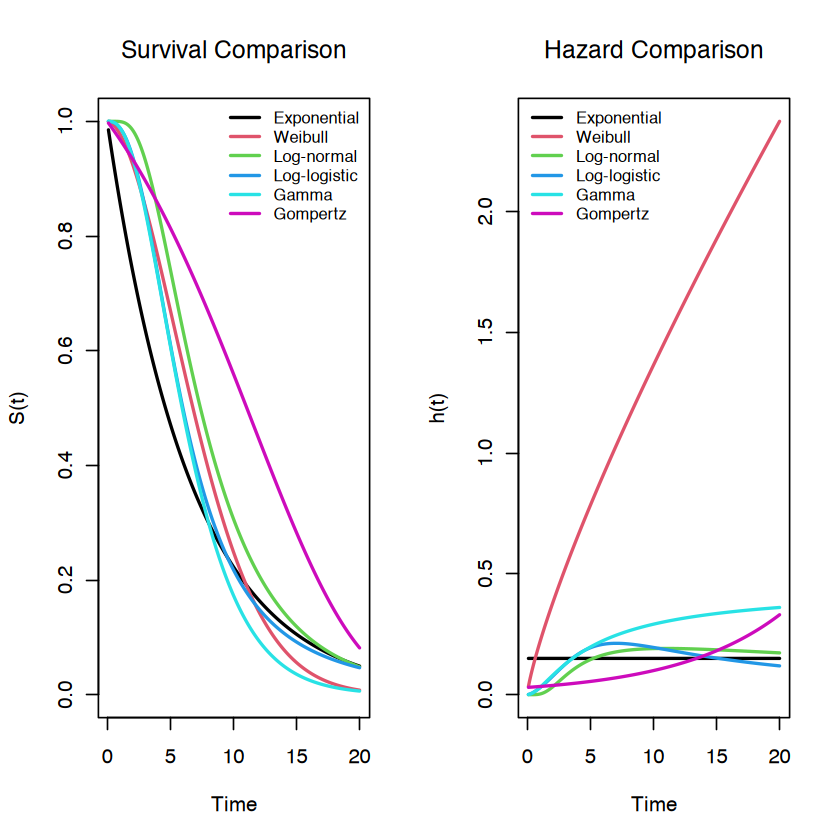

In [24]:
t <- seq(0.1, 20, by = 0.1)

# Exponential
S_exp <- exp(-0.15 * t)
h_exp <- rep(0.15, length(t))

# Weibull
S_weib <- exp(-(0.12 * t)^1.8)
h_weib <- 0.12 * 1.8 * t^(1.8 - 1)

# Log-normal
S_ln <- 1 - plnorm(t, meanlog = 2, sdlog = 0.6)
f_ln <- dlnorm(t, meanlog = 2, sdlog = 0.6)
h_ln <- f_ln / S_ln

# Log-logistic
alpha <- 6; gamma <- 2.5
S_ll <- 1 / (1 + (t / alpha)^gamma)
h_ll <- ((gamma / alpha) * (t / alpha)^(gamma - 1)) / (1 + (t / alpha)^gamma)

# Gamma
S_g <- 1 - pgamma(t, shape = 3, rate = 0.45)
f_g <- dgamma(t, shape = 3, rate = 0.45)
h_g <- f_g / S_g

# Gompertz
lambda <- 0.03; g <- 0.12
h_go <- lambda * exp(g * t)
S_go <- exp(-(lambda / g) * (exp(g * t) - 1))

par(mfrow = c(1,2))

plot(t, S_exp, type = "l", lwd = 2, col = 1, ylim = c(0,1),
     xlab = "Time", ylab = "S(t)", main = "Survival Comparison")
lines(t, S_weib, lwd = 2, col = 2)
lines(t, S_ln,   lwd = 2, col = 3)
lines(t, S_ll,   lwd = 2, col = 4)
lines(t, S_g,    lwd = 2, col = 5)
lines(t, S_go,   lwd = 2, col = 6)
legend("topright",
       legend = c("Exponential", "Weibull", "Log-normal",
                  "Log-logistic", "Gamma", "Gompertz"),
       col = 1:6, lwd = 2, bty = "n", cex = 0.8)

plot(t, h_exp, type = "l", lwd = 2, col = 1,
     xlab = "Time", ylab = "h(t)", main = "Hazard Comparison",
     ylim = c(0, max(h_exp, h_weib, h_ln, h_ll, h_g, h_go, na.rm = TRUE)))
lines(t, h_weib, lwd = 2, col = 2)
lines(t, h_ln,   lwd = 2, col = 3)
lines(t, h_ll,   lwd = 2, col = 4)
lines(t, h_g,    lwd = 2, col = 5)
lines(t, h_go,   lwd = 2, col = 6)
legend("topleft",
       legend = c("Exponential", "Weibull", "Log-normal",
                  "Log-logistic", "Gamma", "Gompertz"),
       col = 1:6, lwd = 2, bty = "n", cex = 0.8)